# Exploratory Data Analysis
- Investigating the business problem by looking and examining our data.
- to see the full dataset, look in the data/ directory.

## Loading the data

In [1]:
# making necesary imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [86]:
df = pd.read_csv("../data/telco_churn.csv")
# here, we see what we are working with

## Examining the data
Trying to answer questions:
1. what does one row represent? ---- a customer
2. is one row one customer? ---- YES
3. which columns seem numerical? ---- tenure, SeniorCitizen, MonthlyCharges, TotalCharges
4. which seem categorical? ---- gender, Partner, Dependents, PhoneService, MultipleLines, InternetService, OnlineSecurity, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, **Contract**, PaperlessBiling, PaymentMethod, **Churn**

*If a customer has been around for only 2 months, are they more likely to leave than someone who stayed 5 years?*

In [87]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Checking dataset structure
This is to:
- check data types
- find missing values (N/As)
- find columns that need conversion

In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [89]:
# checking for blank strings specifically in TotalCharges
print(df['TotalCharges'].value_counts().tail(10))  # shows rare values including blanks

# for a more direct check
blank_mask = df['TotalCharges'].str.strip() == ''
print(f"Blank strings in TotalCharges: {blank_mask.sum()}")

# to fix it, I'll convert to numeric (so the blanks become NaN), then handle
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"NaN count after conversion: {df['TotalCharges'].isna().sum()}")

# these are likely new customers (tenure=0), so filling with 0 makes sense
df['TotalCharges'] = df['TotalCharges'].fillna(0)

TotalCharges
2625.25    1
6886.25    1
1495.1     1
743.3      1
1419.4     1
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, dtype: int64
Blank strings in TotalCharges: 11
NaN count after conversion: 11


#### Observation:
- Churn column is a str type. We'll need to convert it to numeric values.

## Summary statistics
We're looking for:

- Average tenure
- Average monthly charges
- Minimums
- Maximums
- Strange values

In [90]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


#### Observation:
- Average tenure: 32.37
- Average monthly charges: $64.76
- Average SeniorCitizen: 0.162147 * 7043 = 1142.001321 | meaning out of 7043 customers, **about 1142 are senior citizens | about 16.21%**
- Minimums: {
    SeniorCitizen: 0.00,
    tenure: 0.00,
    MonthlyCharges: 18.25
}
- Maximums: {
    SeniorCitizen: 1.00,
    tenure: 72.00,
    MonthlyCharges: 118.75
}
- Strange values: none

## Churn class distribution
This gives us more of a business perspective (maybe 1 in 5 customers leave) as well as the machine learning perspective - whether the dataset is imbalanced or not.

In [91]:
# df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

#### Observation: 
- About 26.5% of customers churned so roughly 1 in 4. 
- The dataset is moderately imbalanced (more non-churners than churners).

#### Insight: 
This imbalance really matters for modeling because a naive model that always predicts "No Churn" would be ~73.5% accurate but completely useless. 
So I'll need to handle this with class weighting or resampling.

### churn rate visualizations
Is churn actually a significant business issue?
- For example, if 30% of customers leave, that's a huge loss.

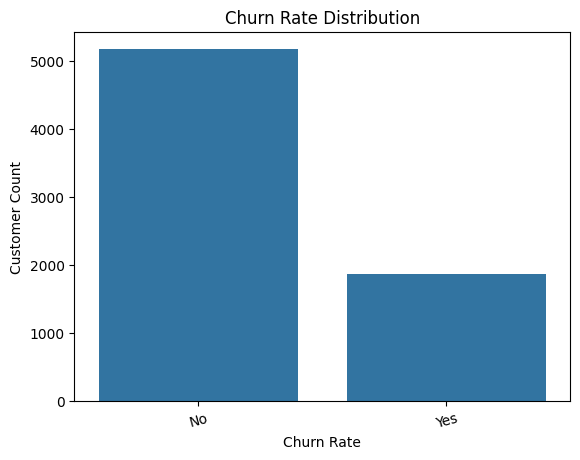

In [92]:
sns.countplot(data=df, x="Churn")
plt.title('Churn Rate Distribution')
plt.ylabel('Customer Count')
plt.xlabel('Churn Rate')
plt.xticks(rotation=15)
plt.show()

## correlation analysis
Where correlation measures: "When one variable changes, does another tend to change?"

An example would be: higer monthly charges -> more churn.
That could be a possible positive correlation.

### Heatmap

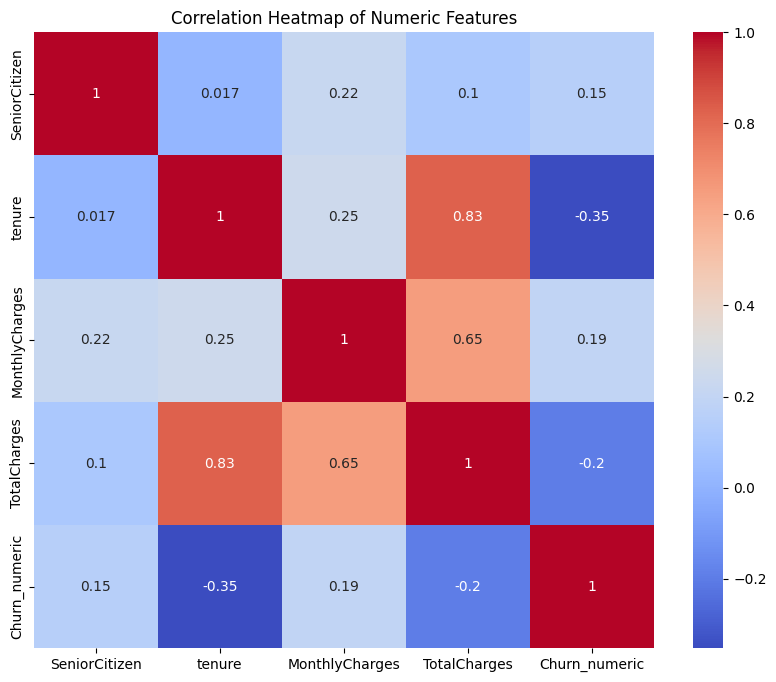

In [93]:
df["Churn_numeric"] = df["Churn"].map({"No":0, "Yes":1})

# defining the corr rule to show correlations between numerical cols
corr = df.corr(numeric_only=True)

#plotting results
plt.figure(figsize=(10,8))

#using seaborn to generate a heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title('Correlation Heatmap of Numeric Features')
plt.show()

#### Insights:
Our target is churn_numeric so focus is on the last row/column
Based on the visuals:
- tenure = -0.35 correlation with Churn (NEGATIVE)
- MonthlyCharges = 0.19 correlation with Churn (POSITIVE)
- SeniorCitizen = 0.15 correlation with Churn (POSITIVE)

**Which variables are closest to churn?**
Here we see that *tenure* has the strongest correlation with Churn and is, thus, the closest.
This means that customers who have been with the company **longer** are less likely to churn. In other words, customers who churn tend to have a shorter tenure.

From this, it means newer customers are leaving more so customer retention efforts may be most valuable during the early stages of the customer lifecycle.

---
**For MonthlyCharges:**
- Customers with higher monthly charges appear *slightly more likely* to churn.
- This is not really a huge effect but it it relatively noticeable.
- Probably the business would have to ask themselves:
    - Do expensive plans create dissatisfaction?
    - Are competitors offering cheaper alternatives?
    - Are high-paying customers receiving enough value?

---
**For SeniorCitizens:**
This has a *weak positive correlation.*
- This means that senior citizens churn *slightly more often* than non-senior customers.
- Because this is a weal relationship, it's not "senior citizens are the reason churn happens" but rather "this might be something worth investigating."

---

Next, we'd have to understand why newer customers are leaving faster

## Contract Type vs Churn
Strong predictor that would be good to examine because:
- Contract type is one of the strongest churn predictors in telco data.
- Month-to-month customers have no long-term commitment, making it easy to leave.

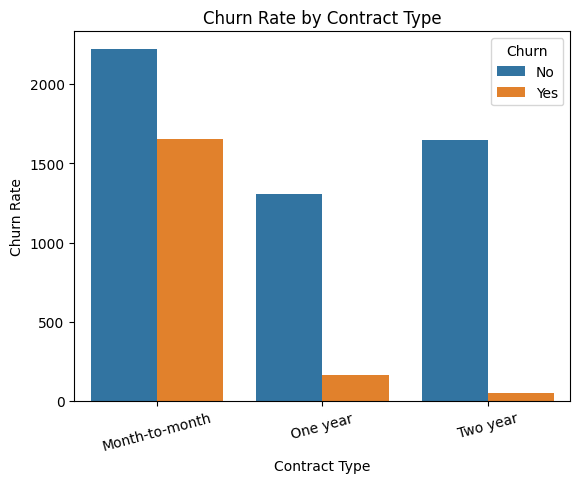

In [94]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xlabel('Contract Type')
plt.xticks(rotation=15)
plt.show()

## Tenure vs Churn (A: Boxplot)
Do churned customers tend to have lower tenure?

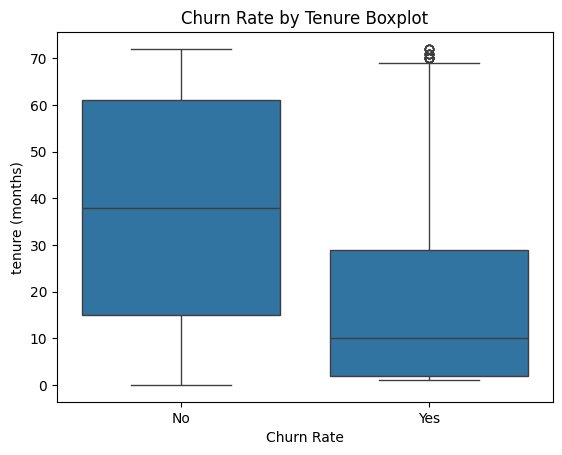

In [95]:
# visualising this correlation with a boxplot
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title('Churn Rate by Tenure Boxplot')
plt.ylabel('tenure (months)')
plt.xlabel('Churn Rate')
plt.show()

#### Observation: 
Customers who churned had a much lower median tenure (~10 months) compared to those who stayed (~38 months). 
The IQR for churners is tight and low; the IQR for non-churners is wide and high.

#### Insight: 
My hypothesis was right, that newer customers churn significantly more. 
Tenure is likely one of the strongest predictive features meaning customers who survive past ~2 years are much more loyal.

## Tenure vs Churn (B: Histogram)
This shows WHERE customers off in their lifecycle.

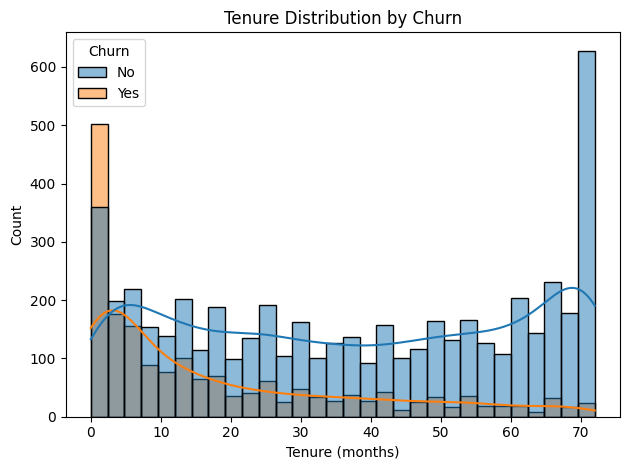

In [96]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.tight_layout()
plt.show()

#### Observation:


#### Insights:


## MonthlyCharges vs Churn
Are customers with higher bills really more likely to leave?

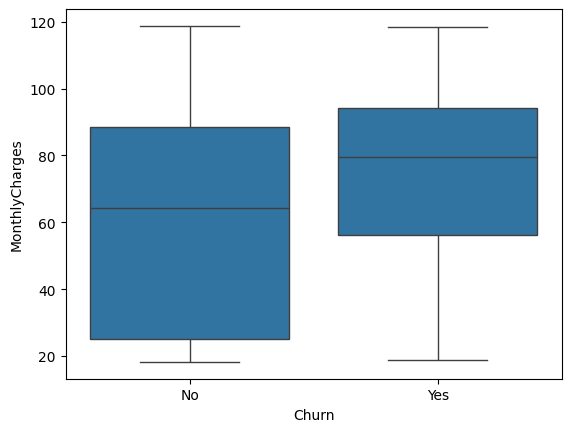

In [97]:
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.show()

#### Observation:
Churned customers had noticeably higher monthly charges (median ~$75) vs. non-churners (~$61). The overlap exists, but the trend is clear.

#### Insights:
Higher bills correlate with higher churn. This is likely linked to contract type (month-to-month customers tend to have higher rates AND churn more). There may be multicollinearity between MonthlyCharges and Contract when modeling.

## Payment Method vs Churn
Assumption: Electronic check users churn more, possibly less committed or more price-sensitive.

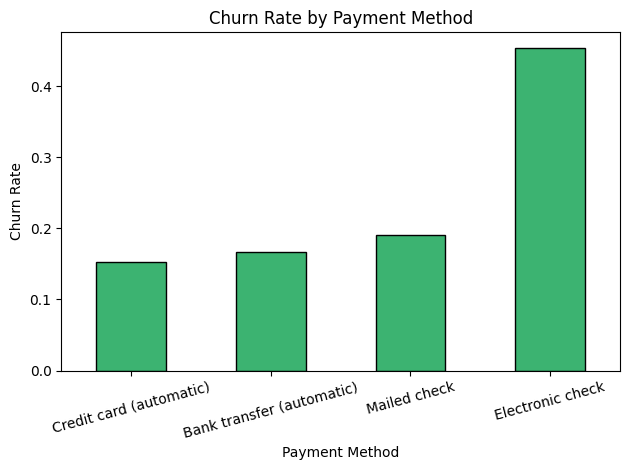

In [98]:
payment_churn = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack()

payment_churn['Yes'].sort_values().plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate')
plt.xlabel('Payment Method')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Churn Rate by Internet Service
Assumption: Fiber optic customers tend to pay more and churn more.


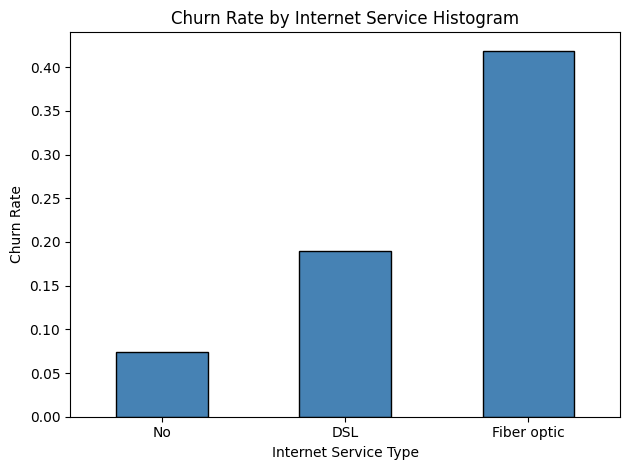

In [99]:
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()

internet_churn['Yes'].sort_values().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Churn Rate by Internet Service Histogram')
plt.ylabel('Churn Rate')
plt.xlabel('Internet Service Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Observations:
Indeed, fiber optic users tend to churn more. They also make up majority of the customers.

##  Categorical Feature Analysis
For each categorical column, what % of customers in each group churned? 

This tells categories are high-risk.

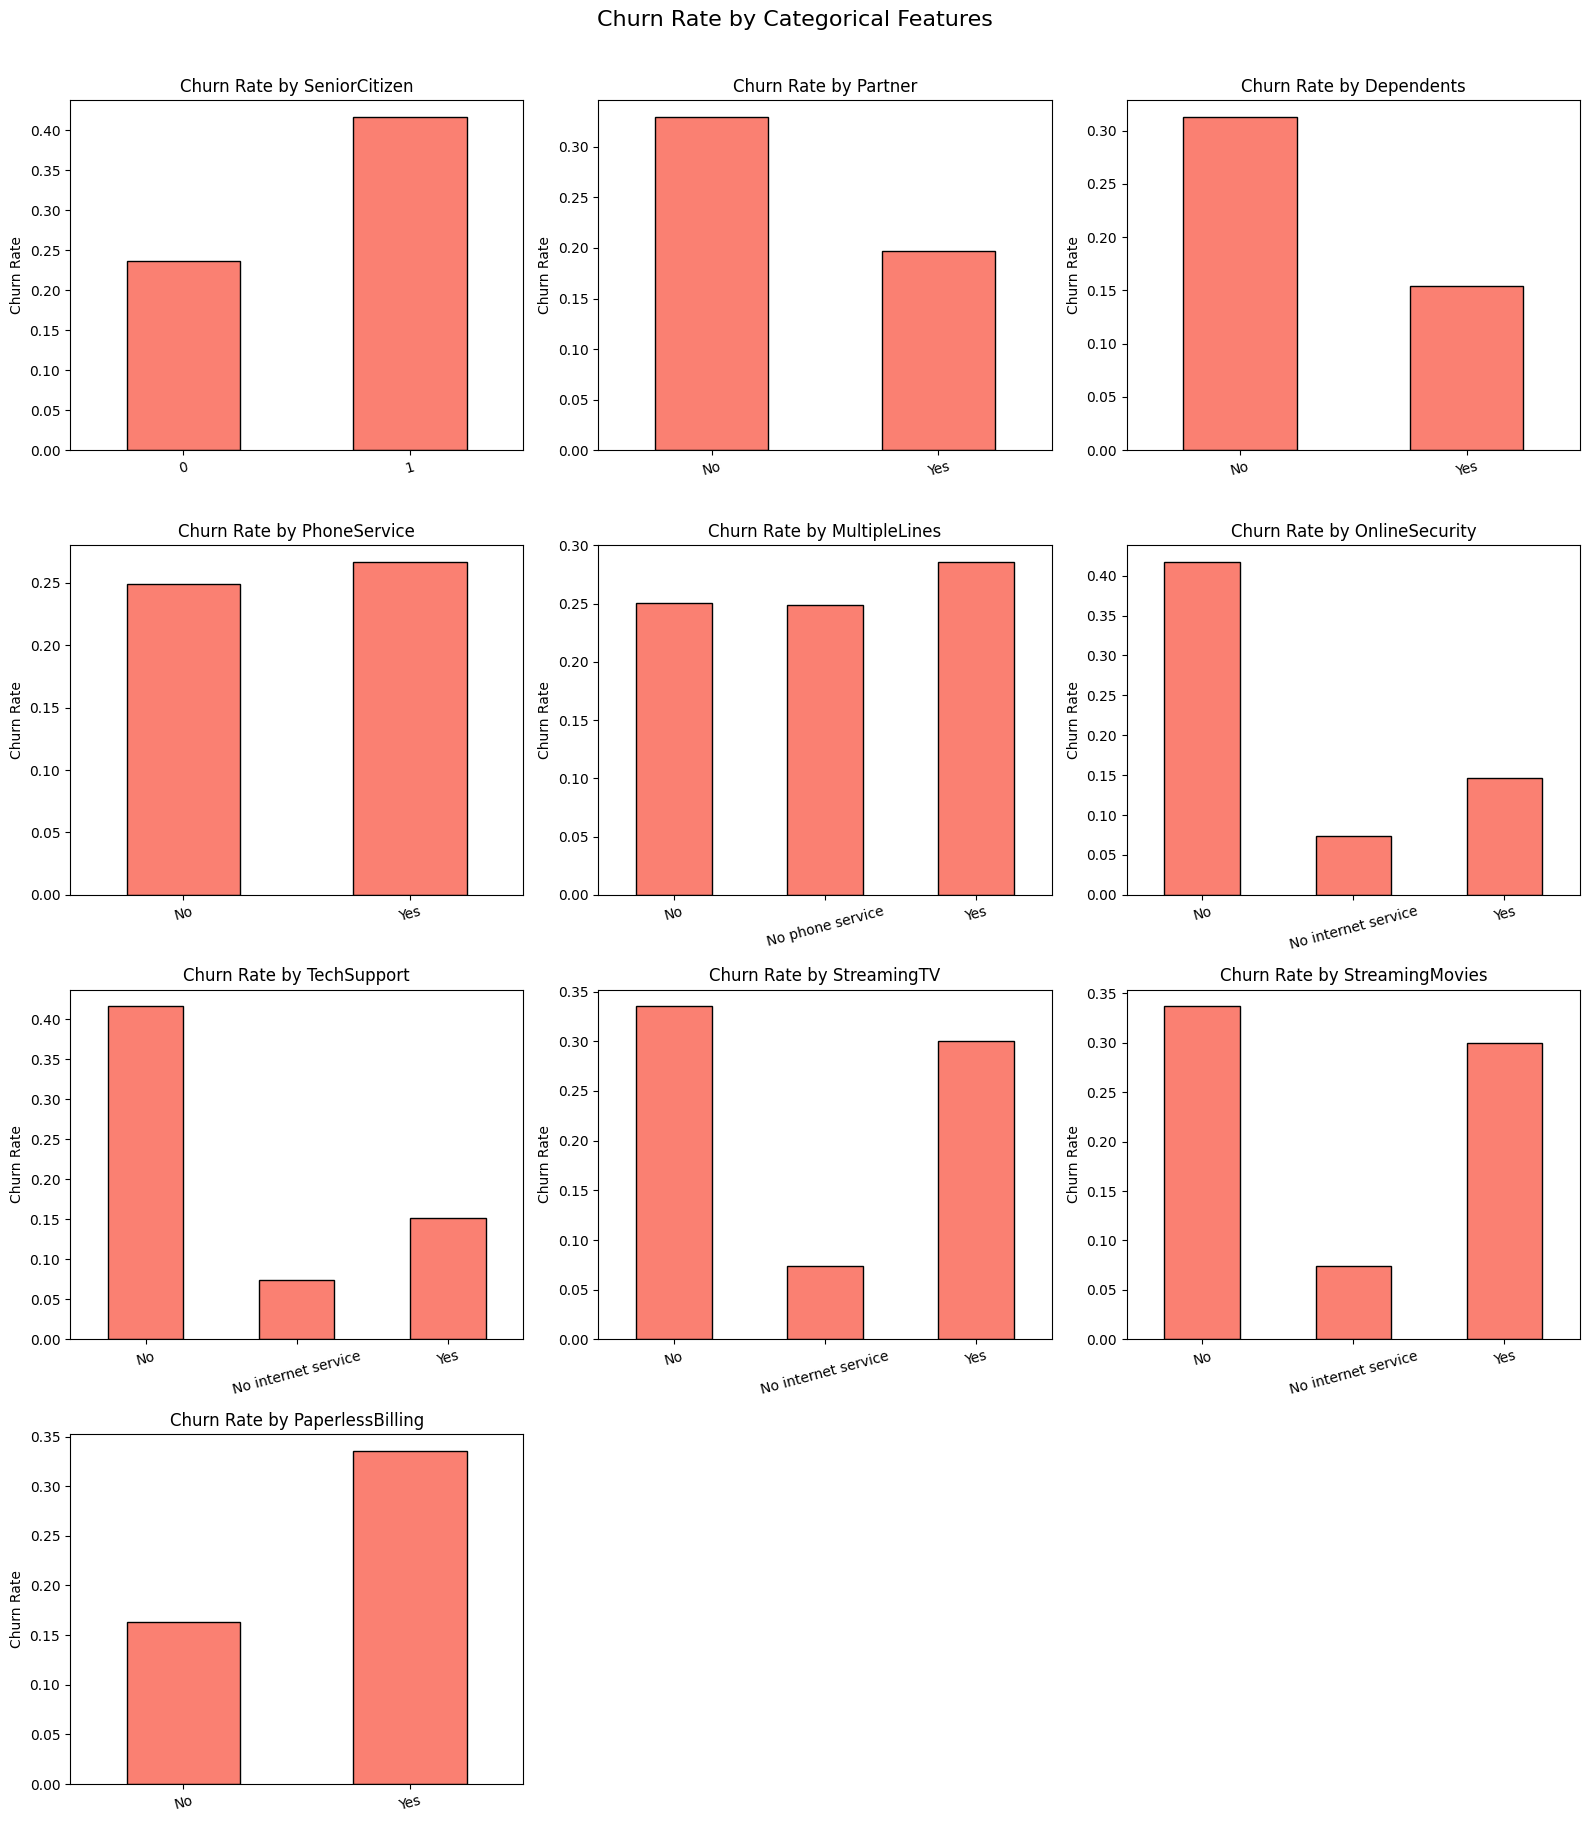

In [100]:
# categorical features worth analyzing
cat_features = [
    'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling'
]

# plotting churn rate for each feature in a grid
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 18))
axes = axes.flatten()

for i, feature in enumerate(cat_features):
    churn_rate = df.groupby(feature)['Churn'].value_counts(normalize=True).unstack()
    churn_rate['Yes'].plot(kind='bar', ax=axes[i], color='salmon', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {feature}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

# hiding any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# EDA SUMMARY - KEY TAKEAWAYS

## What is the data saying?
1. **~26.5% of customers churned**:  a significant business problem worth addressing.
2. **Tenure is the strongest signal**: customers in their first 12 months are at the highest 
   risk of leaving. Loyalty grows sharply after ~2 years.
3. **Contract type is decisive**: month-to-month customers churn at a far higher rate than 
   those on 1- or 2-year contracts. Long-term contracts act as a natural retention mechanism.
4. **Higher monthly charges correlate with churn**: likely because high-cost customers are 
   disproportionately on month-to-month plans with fiber optic internet.
5. **Protective services reduce churn**: customers without OnlineSecurity or TechSupport 
   churn more, suggesting these add-ons increase stickiness.

## Features most likely to be predictive in modeling:
- `tenure`, `Contract`, `MonthlyCharges`, `InternetService`, `OnlineSecurity`, `TechSupport`

## END QUESTIONS REVIEW:
1. **What percentage of customers churn?**
~26.5%. Significant enough to be a real business problem worth solving.

2. **Which customer segments churn the most?**
Based on what's visible: newer customers, higher monthly charges customers, and likely month-to-month contract holders (a classic telco churn pattern in this dataset).

3. **Are newer customers more likely to leave?**
Yes, as strongly confirmed by the tenure boxplot. Low tenure = high churn risk.

4. **Does pricing influence churn?**
Yes, as churners pay more on average monthly. Whether price causes churn or if it's a proxy for contract type needs further digging.

5. **Does contract type influence churn?**
Almost certainly yes (a well-known pattern in this dataset). Month-to-month contracts churn at much higher rates than 1- or 2-year contracts. Worth visualizing explicitly.

6. **Which variables seem most predictive?**
Based on EDA so far: Tenure, MonthlyCharges, and Contract type are the top candidates. SeniorCitizen and lack of OnlineSecurity/TechSupport are also commonly strong signals.

7. **What revenue might be at risk?**
You can estimate: churned_customers × avg_monthly_charge × 12. With ~26.5% churning and median charges around $75, the annual revenue loss is substantial — worth calculating precisely.

8. **What retention strategies seem worth investigating?**
    - Incentivize long-term contracts (discounts for 1-2 year commitments)
    - Early intervention for customers in their first 3–6 months
    - Review pricing for high-charge, month-to-month customers
    - Bundle services (OnlineSecurity, TechSupport) shown to reduce churn


## Business recommendations to explore:
- Incentivize new customers (<12 months) to commit to longer contracts via discounts.
- Promote OnlineSecurity and TechSupport bundles as retention tools.
- Investigate why fiber optic + month-to-month is such a high-churn combination.